In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set up visual style for Seaborn plots
sns.set_theme(style="whitegrid")

# Define the file path (Assuming the final processed file from Session 3)
file_path = 'NSMES1988.csv'

try:
    # Load the DataFrame, using the first column as the index
    df = pd.read_csv(file_path, index_col=0)

    # Convert categorical columns back to 'category' type for memory efficiency and proper plotting
    cat_cols = ['gender', 'married', 'health', 'region', 'employed', 'insurance', 'medicaid', 'adl']
    for col in cat_cols:
        if col in df.columns:
            df[col] = df[col].astype('category')

    print("Data loaded successfully and categorical types optimized.")
    print("DataFrame shape:", df.shape)
    print("\nFirst 5 rows of the processed data:")
    print(df[['age', 'income', 'gender', 'health', 'region']].head())

except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure the data from Capstone Session 3 has been saved as 'NSMES1988updated.csv'.")
    df = None # Set df to None if loading fails


Data loaded successfully and categorical types optimized.
DataFrame shape: (4406, 18)

First 5 rows of the processed data:
   age  income  gender   health region
1  6.9  2.8810    male  average  other
2  7.4  2.7478  female  average  other
3  6.6  0.6532  female     poor  other
4  7.6  0.6588    male     poor  other
5  7.9  0.6588  female  average  other


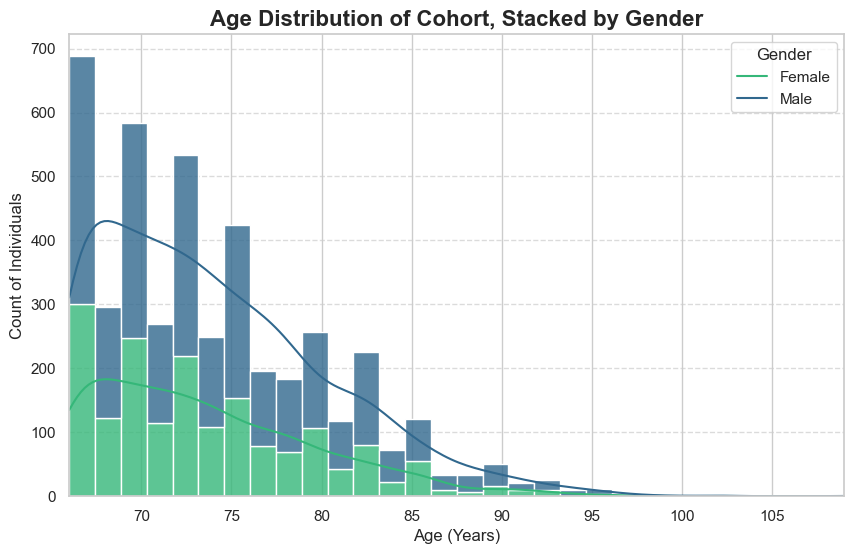

In [3]:
# --- Data Scaling Confirmation (Safety Step from Session 2) ---
# Check the range of 'age' and 'income' and apply scaling if they look denormalized
# The original scaled values were age (x10) and income (x10000).

# If the max age is around 8.0-9.0, it needs to be scaled up.
if df['age'].max() < 100:
    df['age'] = df['age'] * 10
    print("WARNING: 'age' was denormalized and has been scaled up by 10.")
else:
    print("'age' column confirmed to be in years (no scaling needed).")

# If the max income is around 7.0-9.0, it needs to be scaled up.
if df['income'].max() < 10000:
    df['income'] = df['income'] * 10000
    print("WARNING: 'income' was denormalized and has been scaled up by 10000.")
else:
    print("'income' column confirmed to be in actual dollars (no scaling needed).")

# Ensure the age column is properly rounded for clear interpretation (e.g., 65.0, 72.0)
df['age'] = df['age'].round().astype(int)

# --- Visualization 1: Age Distribution by Gender (Task 3 from Session 3) ---

plt.figure(figsize=(10, 6))

# Create a histogram using Seaborn's histplot with KDE (Kernel Density Estimate) overlay
sns.histplot(
    data=df,
    x='age',
    hue='gender',
    multiple='stack', # Stack bars to easily see total count
    kde=True,         # Overlay a smooth line showing the density distribution
    palette='viridis',
    bins=30,          # Set number of bins for granularity
    alpha=0.8
)

# Customize the plot for clarity
plt.title('Age Distribution of Cohort, Stacked by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Age (Years)', fontsize=12)
plt.ylabel('Count of Individuals', fontsize=12)
plt.xlim(df['age'].min(), df['age'].max()) # Set X-limits based on data range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Gender', labels=['Female', 'Male'])

# Display the plot
plt.show()


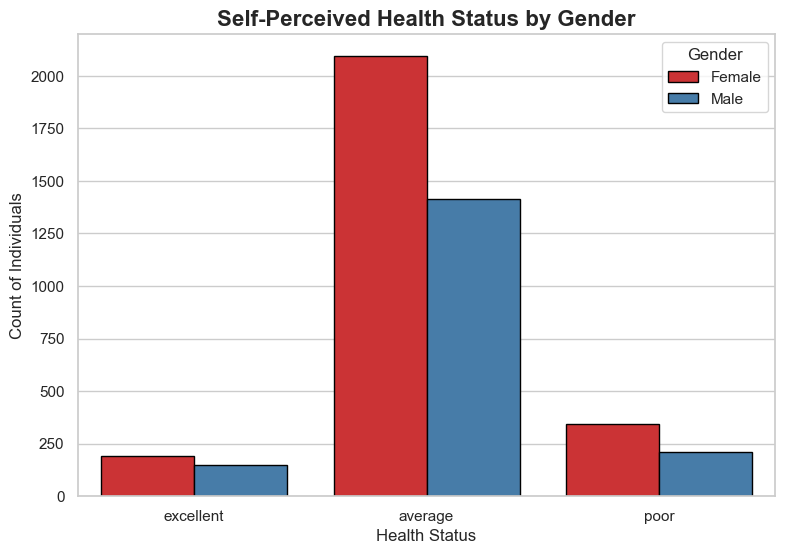

In [4]:
# --- Visualization 2: Health Status by Gender (Task 4 from Session 3) ---

plt.figure(figsize=(9, 6))

# Create a Count Plot to visualize the frequency of each health category,
# segmented by gender.
sns.countplot(
    data=df,
    x='health',
    hue='gender',
    order=['excellent', 'average', 'poor'], # Explicitly set the order for clarity
    palette='Set1',
    edgecolor='black'
)

# Customize the plot
plt.title('Self-Perceived Health Status by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Health Status', fontsize=12)
plt.ylabel('Count of Individuals', fontsize=12)
plt.legend(title='Gender', labels=['Female', 'Male'])
plt.xticks(rotation=0) # Ensure labels are horizontal

# Display the plot
plt.show()


/var/folders/0q/xf9ydzjn1g1963ctltkj0gjw0000gn/T/ipykernel_35349/3162701626.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


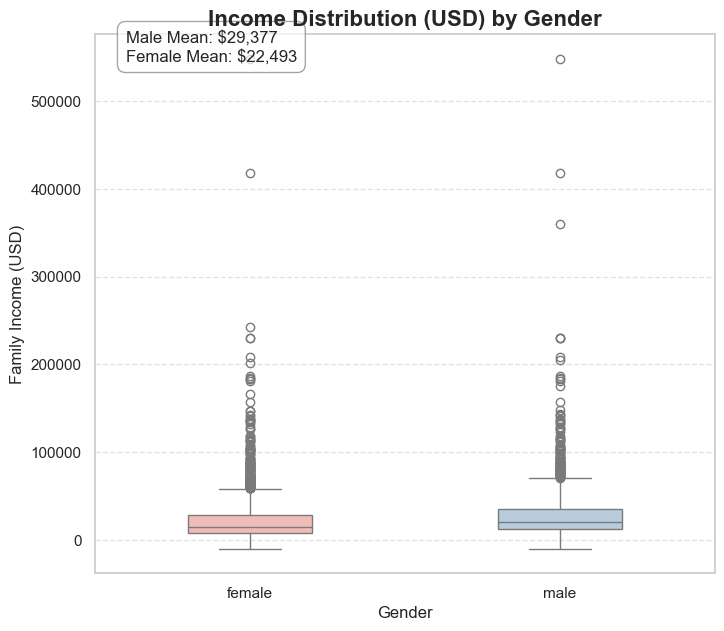

In [5]:
# --- Visualization 3: Income Distribution by Gender (Task 3 from Session 3) ---

plt.figure(figsize=(8, 7))

# Create a Box Plot to show the five-number summary (min, Q1, median, Q3, max)
# of income for each gender.
sns.boxplot(
    data=df,
    x='gender',
    y='income',
    palette='Pastel1',
    width=0.4
)

# Customize the plot
plt.title('Income Distribution (USD) by Gender', fontsize=16, fontweight='bold')
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Family Income (USD)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Add a concise text summary to the plot area to highlight key findings (optional but helpful)
# Note: Based on Session 3 analysis, males had a slightly higher mean income.
mean_income_male = df[df['gender'] == 'male']['income'].mean()
mean_income_female = df[df['gender'] == 'female']['income'].mean()

plt.text(0.05, 0.95,
         f"Male Mean: ${mean_income_male:,.0f}\nFemale Mean: ${mean_income_female:,.0f}",
         transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray', boxstyle='round,pad=0.5'))

# Display the plot
plt.show()
